# Pipeline Predictivo de Compras

Demostración interactiva del pipeline DVC productivo:  
`load` → `preprocess` → `featurize` → `train` → `evaluate`

Cada paso usa los módulos de `src/` tal como los ejecuta el pipeline.

**Requisitos previos:** Tener `data/processed/initial_sales_clean.parquet` generado por `load_data.py`.

---

## 1. Setup e Importaciones

In [1]:
import os
import sys
from pathlib import Path

# Fijar directorio de trabajo en la raíz del proyecto
# (las rutas de params.yaml son relativas a la raíz)
os.chdir(Path("..").resolve())
sys.path.insert(0, "src")

import logging
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_auc_score, brier_score_loss, classification_report,
    confusion_matrix
)
from sklearn.calibration import CalibrationDisplay, CalibratedClassifierCV

from config import load_config, processed_path, model_dir, reports_dir, plots_dir
from data_io import load_parquet, load_product_catalog, load_calendar_features, load_calibrated_model
from patterns import filter_recent_clients, compute_purchase_patterns, apply_pattern_filters
from train import temporal_split

logging.basicConfig(level=logging.INFO, format="%(levelname)s - %(message)s")
plt.rcParams["figure.figsize"] = (8, 5)

cfg = load_config("params.yaml")
print(f"Directorio de trabajo: {os.getcwd()}")
print("Config cargada correctamente")

Directorio de trabajo: /Users/juandavidrincon/Documents/euro_nuevo_nov/euro
Config cargada correctamente


## 2. Carga de Datos

Datos de ventas limpios generados por `src/load_data.py` (etapa DVC `load`).

In [2]:
proc = processed_path(cfg)
sales = load_parquet(proc / cfg["data"]["sales_file"], "Ventas")

print(f"Filas: {len(sales):,}")
print(f"Rango de fechas: {sales['date_sale'].min().date()} → {sales['date_sale'].max().date()}")
print(f"Clientes únicos: {sales['id_client'].nunique():,}")
sales.head()

2026-03-10 19:15:57,960 - INFO - Ventas cargado: 13370893 filas desde data/processed/initial_sales_clean.parquet


Filas: 13,370,893
Rango de fechas: 2025-07-01 → 2025-11-06
Clientes únicos: 232,722


,date_sale,id_client,product,invoice_value_with_discount_and_without_iva,amount,id_point_sale
4921657,2025-07-01,15263501,331269,111376.0,4.0,SAL
4921658,2025-07-01,15263501,329947,111376.0,2.0,SAL
4921659,2025-07-01,15263501,331547,111376.0,2.0,SAL
4921660,2025-07-01,15263501,326665,111376.0,2.0,SAL
4921661,2025-07-01,1037597240,332257,34410.0,1.0,SAL


## 3. Preprocesamiento — Patrones de Compra

Replica `src/preprocess.py` (etapa DVC `preprocess`).

**Proceso:**
1. Filtrar clientes con actividad reciente (últimos N meses).
2. Calcular patrones de compra por cliente (mediana, std de días entre compras, productos distintos).
3. Aplicar filtros de regularidad para quedarse con clientes predecibles.

In [3]:
pre_cfg = cfg["preprocess"]

# 3.1 Filtrar por actividad reciente
recent = filter_recent_clients(
    sales,
    months=cfg["data"]["last_month_with_sale"],
)
print(f"Clientes con actividad reciente: {recent['id_client'].nunique():,}")

2026-03-10 19:16:01,107 - INFO - Clientes últimos 3 meses (ref: 2025-11-06, corte: 2025-08-08): 199309


Clientes con actividad reciente: 199,309


In [4]:
# 3.2 Calcular patrones de compra
patterns = compute_purchase_patterns(
    recent,
    amount_col="invoice_value_with_discount_and_without_iva",
)
print(f"Clientes con patrones calculados: {len(patterns):,}")
patterns.describe().round(2)

Clientes con patrones calculados: 199,309


,purchase_days,median_days_between,std_days_between,product_distinct,pay_amount_mean
count,199309.00,138500.00,107268.00,199309.00,199309.00
mean,6.01,21.58,12.43,42.79,126758.14
std,8.95,20.59,10.73,55.39,196427.88
min,1.00,1.00,0.00,1.00,126.00
25%,1.00,7.00,5.24,6.00,31133.50
50%,3.00,14.00,9.21,20.00,69368.69
75%,7.00,28.50,15.91,58.00,152292.75
max,124.00,128.00,88.39,686.00,19619204.33


In [5]:
# 3.3 Filtrar por regularidad
valid_clients = apply_pattern_filters(
    patterns,
    min_purchase_days=pre_cfg["min_purchase_days_filter"],
    max_median_days=pre_cfg["max_median_days_between"],
    max_std_days=pre_cfg["max_std_days_between"],
    min_products=pre_cfg["min_products_filter"],
)
print(f"Clientes que pasan todos los filtros: {len(valid_clients):,}")

2026-03-10 19:16:11,999 - INFO - Filtro de patrones: 199309 -> 6426 clientes válidos


Clientes que pasan todos los filtros: 6,426


## 4. Features — Calendario Completo

Carga la salida de `src/featurize.py` (etapa DVC `featurize`).  
Crea un calendario cliente-fecha con variables temporales y ventanas móviles (con `shift(1)` para evitar fuga).

| Grupo | Variables |
|---|---|
| Temporales | `dow`, `dom`, `month`, `is_weekend`, `is_quincena` |
| Recencia | `days_since_last` |
| Ventanas móviles | `cnt_1d`, `cnt_3d`, `cnt_7d`, `cnt_15d`, `cnt_30d` |

In [6]:
calendar = load_calendar_features(cfg)

print(f"Filas en calendario: {len(calendar):,}")
print(f"Clientes: {calendar['client'].nunique():,}")
print(f"Rango: {calendar['date'].min().date()} → {calendar['date'].max().date()}")
print(f"\nDistribución de target (purchased):")
print(calendar["purchased"].value_counts(normalize=True).round(4))
calendar.head()

2026-03-10 19:16:13,429 - INFO - Calendario cargado: 861084 filas desde data/processed/calendar_features.parquet


Filas en calendario: 861,084
Clientes: 6,426
Rango: 2025-07-01 → 2025-11-11

Distribución de target (purchased):
purchased
0    0.7042
1    0.2958
Name: proportion, dtype: float64


,client,date,qty_tot,amount_tot,skus,purchased,dow,dom,month,is_weekend,is_quincena,days_since_last,cnt_1d,cnt_3d,cnt_7d,cnt_15d,cnt_30d
0,1000088250,2025-07-01,1.16,1584.0,2,1,1,1,7,0,1,0,0.0,0.0,0.0,0.0,0.0
1,1000088250,2025-07-02,1.00,14306.0,1,1,2,2,7,0,1,0,1.0,1.0,1.0,1.0,1.0
2,1000088250,2025-07-03,3.00,17461.0,3,1,3,3,7,0,0,0,1.0,2.0,2.0,2.0,2.0
3,1000088250,2025-07-04,0.00,0.0,0,0,4,4,7,0,0,1,1.0,3.0,3.0,3.0,3.0
4,1000088250,2025-07-05,0.00,0.0,0,0,5,5,7,1,0,2,0.0,2.0,3.0,3.0,3.0


## 5. Entrenamiento — Regresión Logística

Replica `src/train.py` (etapa DVC `train`).  
Split temporal: los últimos `split_days_validation` días son validación.

In [7]:
train_cfg = cfg["train"]
features = train_cfg["features"]
target = train_cfg["target"]

X_train, y_train, X_valid, y_valid = temporal_split(
    calendar,
    split_days=train_cfg["split_days_validation"],
    target=target,
    features=features,
)

print(f"Features: {features}")
print(f"Train: {X_train.shape} | pos={y_train.mean():.3f}")
print(f"Valid: {X_valid.shape} | pos={y_valid.mean():.3f}")

2026-03-10 19:16:14,610 - INFO - Split temporal | train <= 2025-10-07 | valid 2025-10-08 -> 2025-11-06
2026-03-10 19:16:14,677 - INFO - Train (636174, 11) | pos=0.315 — Valid (192780, 11) | pos=0.281


Features: ['dow', 'dom', 'month', 'is_weekend', 'is_quincena', 'days_since_last', 'cnt_1d', 'cnt_3d', 'cnt_7d', 'cnt_15d', 'cnt_30d']
Train: (636174, 11) | pos=0.315
Valid: (192780, 11) | pos=0.281


In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

lr_cfg = train_cfg["logistic_regression"]
seed = cfg["base"]["random_state"]

pipe = make_pipeline(
    StandardScaler(with_mean=False),
    LogisticRegression(
        solver=lr_cfg["solver"],
        max_iter=lr_cfg["max_iter"],
        tol=lr_cfg["tol"],
        C=lr_cfg["C"],
        class_weight=lr_cfg["class_weight"],
        random_state=seed,
        n_jobs=-1,
    ),
)
pipe.fit(X_train, y_train)
print(f"Iteraciones: {pipe.named_steps['logisticregression'].n_iter_[0]}")

Iteraciones: 53


## 6. Evaluación — Métricas y Calibración

Replica `src/evaluate.py` (etapa DVC `evaluate`).  
Calibra con `CalibratedClassifierCV(method='sigmoid', cv='prefit')` sobre validación.

In [10]:
# 6.1 Modelo base
y_prob_base = pipe.predict_proba(X_valid)[:, 1]

print("=== Modelo Base ===")
print(f"ROC-AUC: {roc_auc_score(y_valid, y_prob_base):.3f}")
print(f"Brier:   {brier_score_loss(y_valid, y_prob_base):.3f}")
print(classification_report(y_valid, pipe.predict(X_valid), digits=3))

=== Modelo Base ===
ROC-AUC: 0.702
Brier:   0.189
              precision    recall  f1-score   support

           0      0.770     0.894     0.828    138676
           1      0.538     0.317     0.399     54104

    accuracy                          0.732    192780
   macro avg      0.654     0.605     0.613    192780
weighted avg      0.705     0.732     0.707    192780



In [11]:
# 6.2 Calibración
import warnings
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=UserWarning)
    cal = CalibratedClassifierCV(pipe, method="sigmoid", cv="prefit")
    cal.fit(X_valid, y_valid)

y_prob_cal = cal.predict_proba(X_valid)[:, 1]
thr = cfg["evaluate"]["evaluation_threshold"]

print("=== Modelo Calibrado ===")
print(f"ROC-AUC: {roc_auc_score(y_valid, y_prob_cal):.3f}")
print(f"Brier:   {brier_score_loss(y_valid, y_prob_cal):.3f}")

y_pred_thr = (y_prob_cal >= thr).astype(int)
print(f"\nCon umbral={thr}:")
print(classification_report(y_valid, y_pred_thr, digits=3))

=== Modelo Calibrado ===
ROC-AUC: 0.702
Brier:   0.180

Con umbral=0.5:
              precision    recall  f1-score   support

           0      0.755     0.942     0.838    138676
           1      0.594     0.218     0.319     54104

    accuracy                          0.739    192780
   macro avg      0.675     0.580     0.578    192780
weighted avg      0.710     0.739     0.692    192780



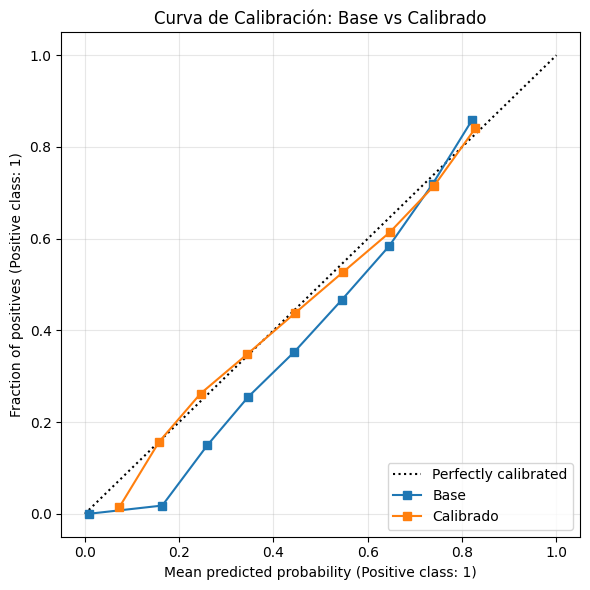

In [12]:
# 6.3 Curva de calibración
fig, ax = plt.subplots(figsize=(6, 6))
CalibrationDisplay.from_estimator(pipe, X_valid, y_valid, n_bins=10, name="Base", ax=ax)
CalibrationDisplay.from_estimator(cal, X_valid, y_valid, n_bins=10, name="Calibrado", ax=ax)
ax.set_title("Curva de Calibración: Base vs Calibrado")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

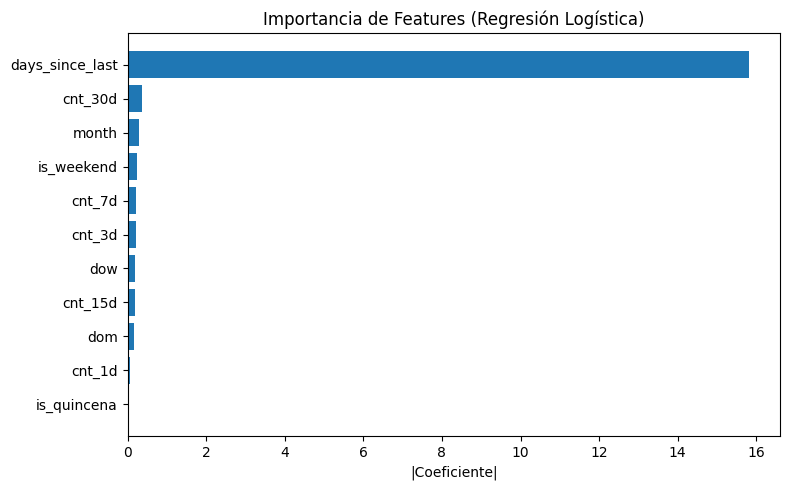

In [13]:
# 6.4 Importancia de features (|coeficientes|)
logreg = pipe.named_steps["logisticregression"]
importance = pd.DataFrame({
    "feature": features,
    "importance": np.abs(logreg.coef_[0]),
}).sort_values("importance", ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(importance["feature"], importance["importance"])
ax.set_xlabel("|Coeficiente|")
ax.set_title("Importancia de Features (Regresión Logística)")
plt.tight_layout()
plt.show()

## 7. Predicción — Ejemplo

Muestra cómo se genera la predicción para una fecha futura usando el modelo calibrado.

In [14]:
# Predecir para la última fecha disponible en el calendario
fecha_pred = calendar["date"].max()
future_df = calendar[calendar["date"] == fecha_pred].copy()
future_df["prob"] = cal.predict_proba(future_df[features])[:, 1]

high = future_df[future_df["prob"] >= thr].sort_values("prob", ascending=False)

print(f"Fecha de predicción: {fecha_pred.date()}")
print(f"Clientes con prob >= {thr}: {len(high)}")
print(f"Probabilidad media: {high['prob'].mean():.3f}")
high[["client", "prob"]].head(10)

Fecha de predicción: 2025-11-11
Clientes con prob >= 0.5: 99
Probabilidad media: 0.545


,client,prob
818337,901569974,0.634648
825841,901813727,0.634648
741823,800180330,0.634648
150213,11156976,0.634648
162407,1128449916,0.634648
813647,901302833,0.634648
189073,1235245925,0.634648
93665,1038358432,0.614019
170581,1143458220,0.614019
828119,901913830,0.614019


---

**Para ejecutar el pipeline completo de forma automática:**

```bash
uv run dvc repro
```

**Para generar predicciones con recomendaciones:**

```bash
uv run python src/predict.py --dates 2025-11-07 --threshold 0.5
```